# Solar-GeoTwin: GeoAI Project Analytics


**Author:** Davide Ferreri

**Role:** Industrial Engineer / AI Architect

**Objective:** Analyzing the fusion of Sentinel-2 imagery and Terrain data for Solar Site Selection.


## Imports


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
import sys
import json
import glob
from pathlib import Path

## Path setup to access modules


In [34]:
# 1. Find the project root (one level up from /notebooks)
notebook_path = Path(os.getcwd())
PROJECT_ROOT = notebook_path.parent

# 2. Add root to sys.path so we can import our modules
sys.path.append(str(PROJECT_ROOT))

# 3. Define data paths relative to the root
IMAGE_DIR = PROJECT_ROOT / "data" / "images"
MASK_DIR = PROJECT_ROOT / "data" / "masks"
MODEL_PATH = PROJECT_ROOT / "models" / "solar_unet_v1.pth"
HISTORY_PATH = PROJECT_ROOT / "models" / "training_history_v1.json"

print(f"Project Root identified as: {PROJECT_ROOT}")

Project Root identified as: /Users/davideferreri/Documents/GitHub/Solar-GeoTwin


## 1. Training Performance Analysis

Loading the history from JSON to verify convergence across global biomes.


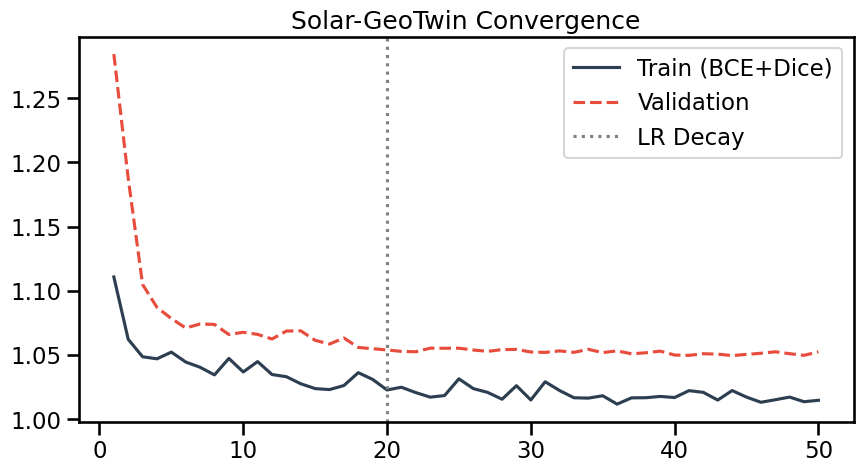

In [39]:
from modules.ai_engine import SolarUNet

# Set style for professional plots
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")

try:
    with open(HISTORY_PATH, "r") as f:
        history = json.load(f)
    
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history["train_loss"], label='Train (BCE+Dice)', color='#2c3e50')
    plt.plot(epochs, history["val_loss"], label='Validation', color='#e74c3c', linestyle='--')
    plt.axvline(x=20, color='gray', linestyle=':', label='LR Decay')
    plt.title("Solar-GeoTwin Convergence")
    plt.legend()
    plt.show()
except FileNotFoundError:
    print(f"⚠️ History file not found at {HISTORY_PATH}")

## 2. Global Biome Validation

Testing the model's ability to generalize by sampling specific regions.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0788].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0582..1.7939999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0876..1.677].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3126..1.3266001].


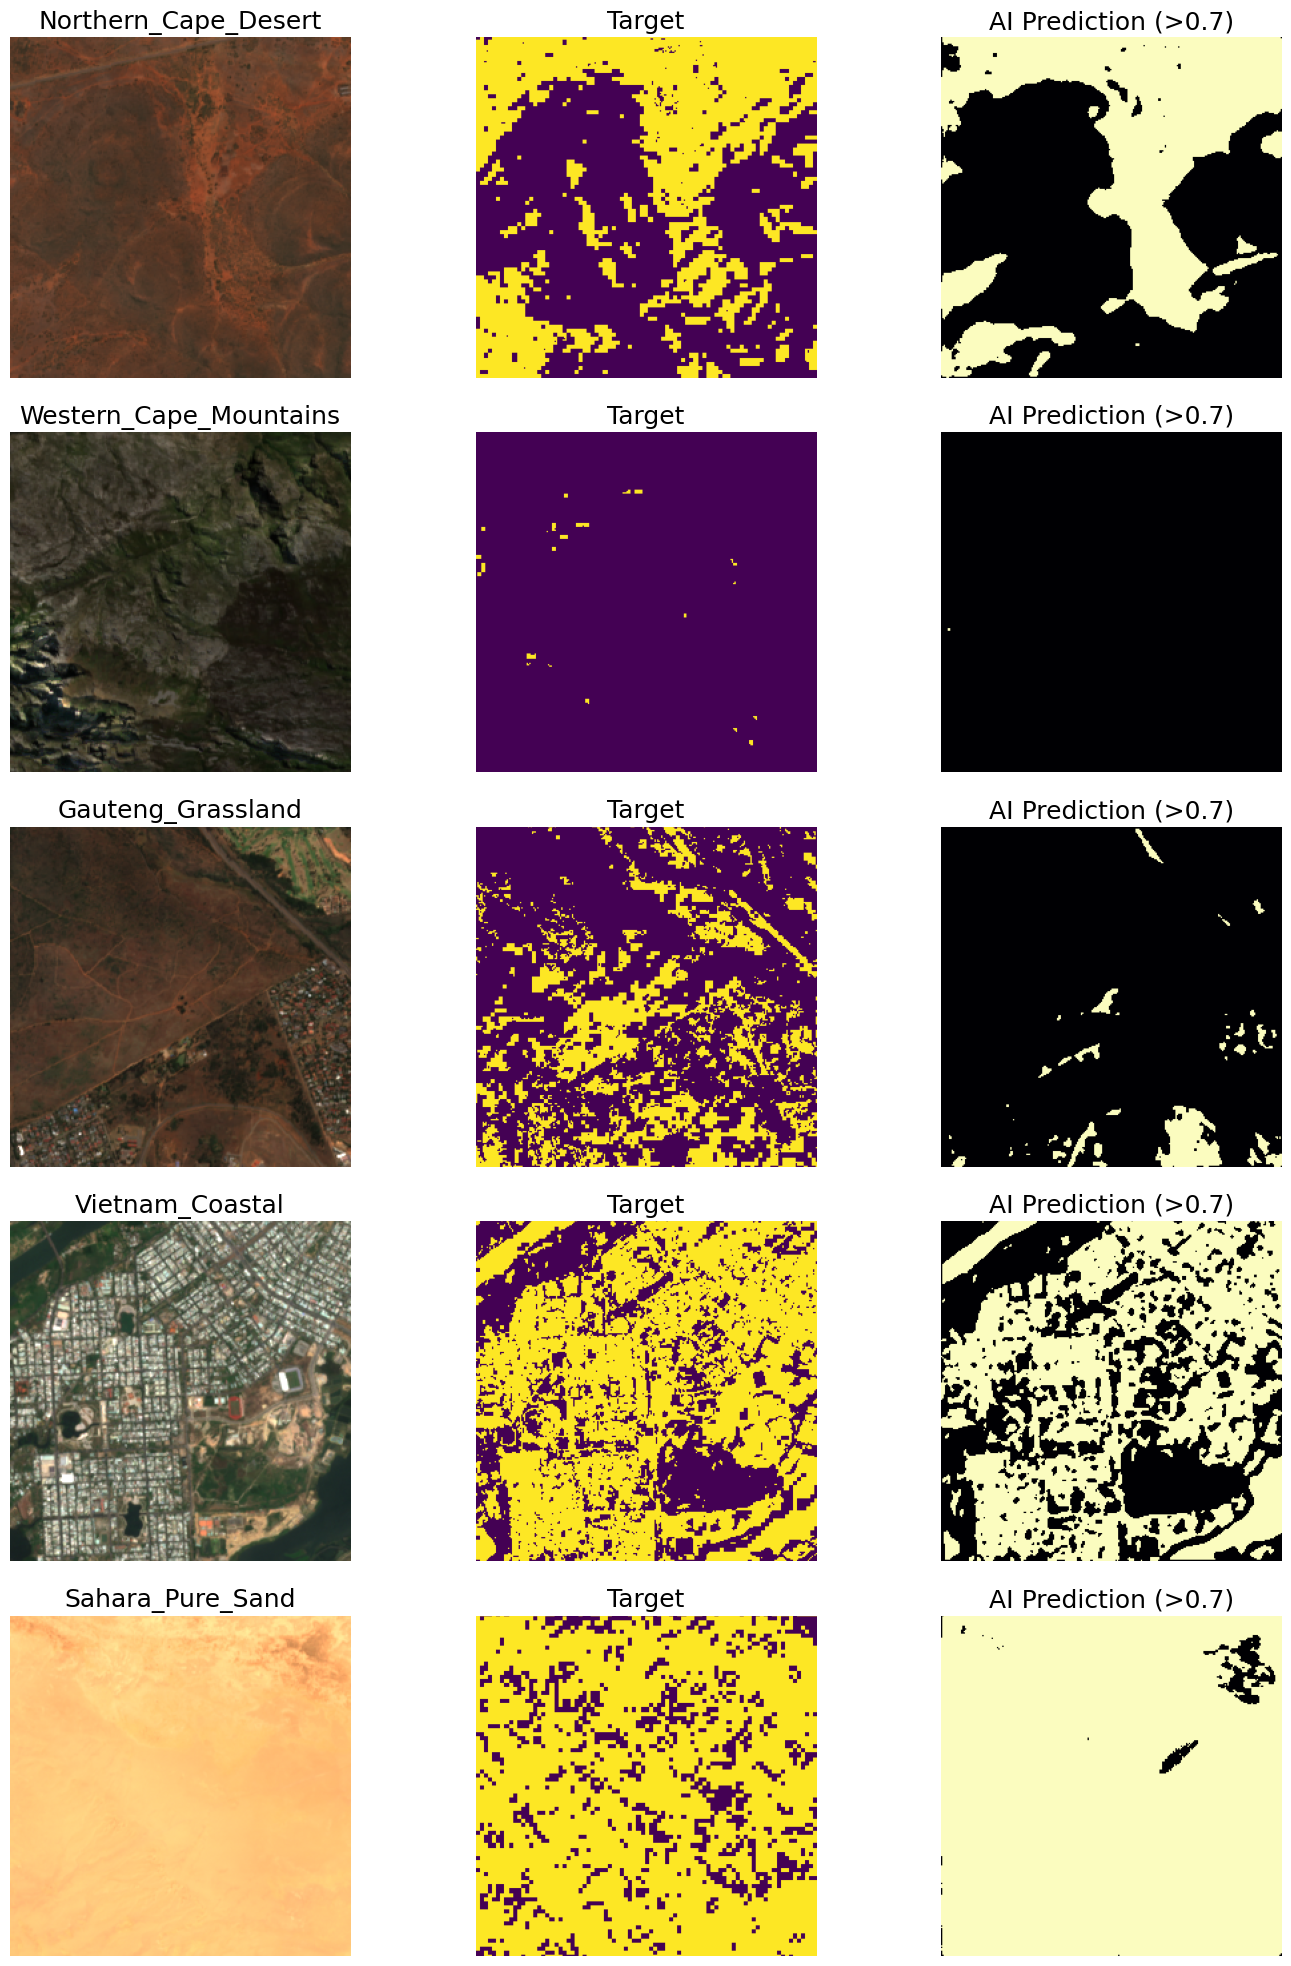

In [40]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = SolarUNet(in_channels=4, out_channels=1).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Select one sample patch from each biome we downloaded
biomes = ["Northern_Cape_Desert", "Western_Cape_Mountains", "Gauteng_Grassland", "Vietnam_Coastal", "Sahara_Pure_Sand"]
threshold = 0.7  # Calibrated based on heatmap analysis

fig, axes = plt.subplots(len(biomes), 3, figsize=(15, 4 * len(biomes)))

for i, biome in enumerate(biomes):
    img_p = IMAGE_DIR / f"{biome}_patch_0.npy"
    msk_p = MASK_DIR / f"{biome}_patch_0.npy"
    
    if img_p.exists():
        img = np.load(img_p)
        mask = np.load(msk_p)
        
        # Inference Pipeline
        # Transpose: (H, W, C) -> (C, H, W) and add Batch dimension
        tensor = torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
        
        with torch.no_grad():
            output = model(tensor)
            probs = torch.sigmoid(output).squeeze().cpu().numpy()
        
        # Plotting
        axes[i, 0].imshow(img[:,:,:3] * 3) # RGB
        axes[i, 0].set_title(f"{biome}")
        
        axes[i, 1].imshow(mask, cmap='viridis') # Ground Truth
        axes[i, 1].set_title("Target")
        
        # Visualize where probability crosses our calibrated threshold
        axes[i, 2].imshow(probs > threshold, cmap='magma')
        axes[i, 2].set_title(f"AI Prediction (>{threshold})")
        
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.show()